In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/energy_data_set.csv")
print(df.shape)
print(df.columns.tolist())

(19735, 29)
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


In [2]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

print("Date range:", df.index.min(), "to", df.index.max())
print("Missing values:", df.isna().sum().sum())
print("Duplicate timestamps:", df.index.duplicated().sum())
print(df.index.to_series().diff().value_counts().head())
print(df["Appliances"].describe())

Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Missing values: 0
Duplicate timestamps: 0
date
0 days 00:10:00    19734
Name: count, dtype: int64
count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


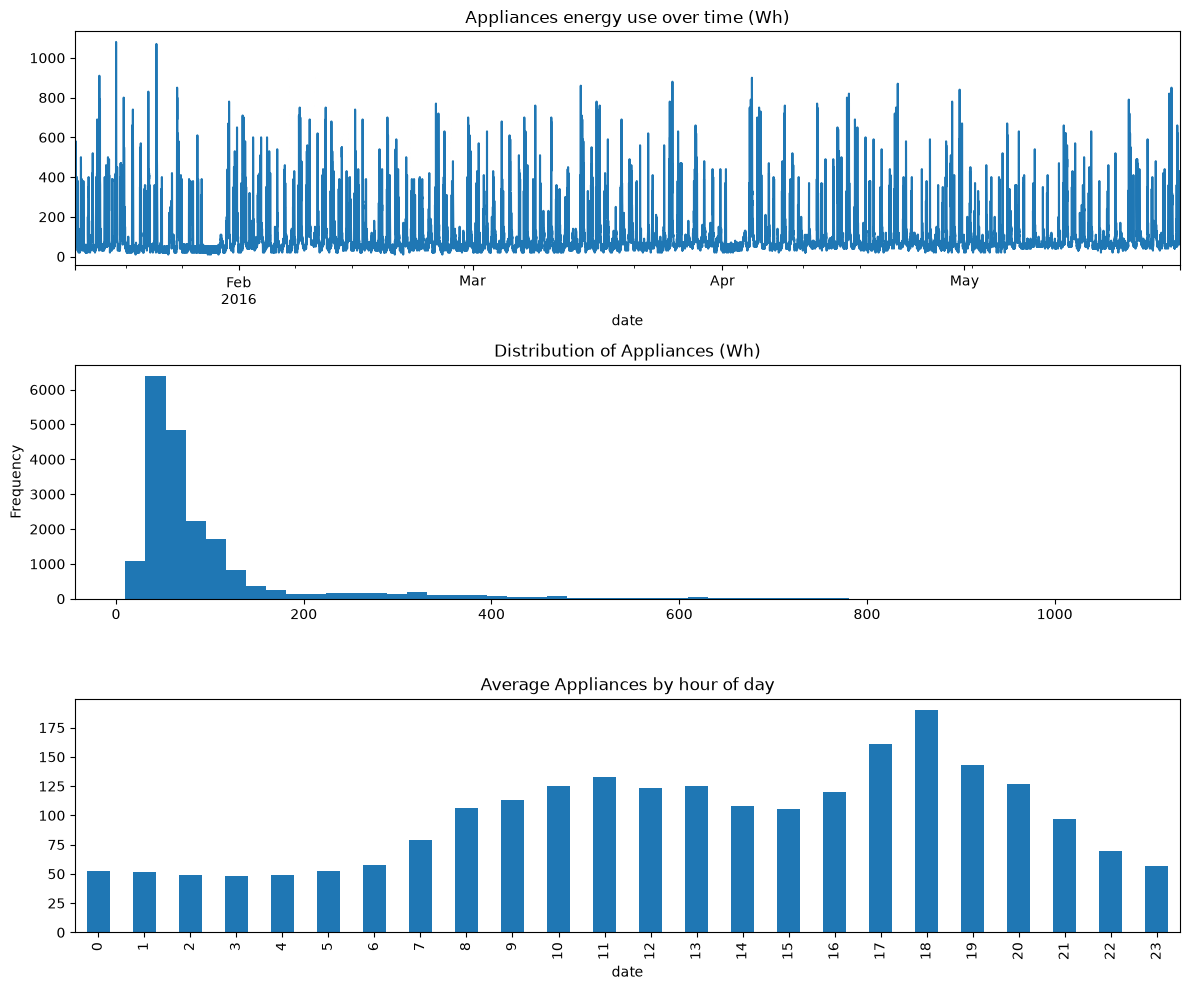

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df["Appliances"].plot(ax=axes[0], title="Appliances energy use over time (Wh)")
df["Appliances"].plot(kind="hist", bins=50, ax=axes[1], title="Distribution of Appliances (Wh)")
df.groupby(df.index.hour)["Appliances"].mean().plot(
    kind="bar", ax=axes[2], title="Average Appliances by hour of day"
)

plt.tight_layout()
plt.show()

IQR upper bound: 175 Wh
Rows above it: 2138 (10.8%)


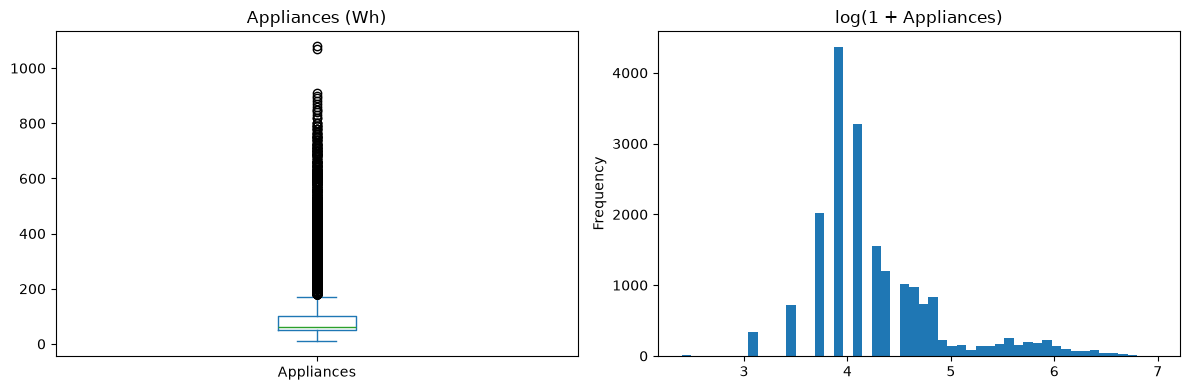

In [4]:
import numpy as np

q1, q3 = df["Appliances"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
n_out = (df["Appliances"] > upper).sum()
print(f"IQR upper bound: {upper:.0f} Wh")
print(f"Rows above it: {n_out} ({n_out / len(df):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Appliances"].plot(kind="box", ax=axes[0], title="Appliances (Wh)")
np.log1p(df["Appliances"]).plot(kind="hist", bins=50, ax=axes[1], title="log(1 + Appliances)")
plt.tight_layout()
plt.show()

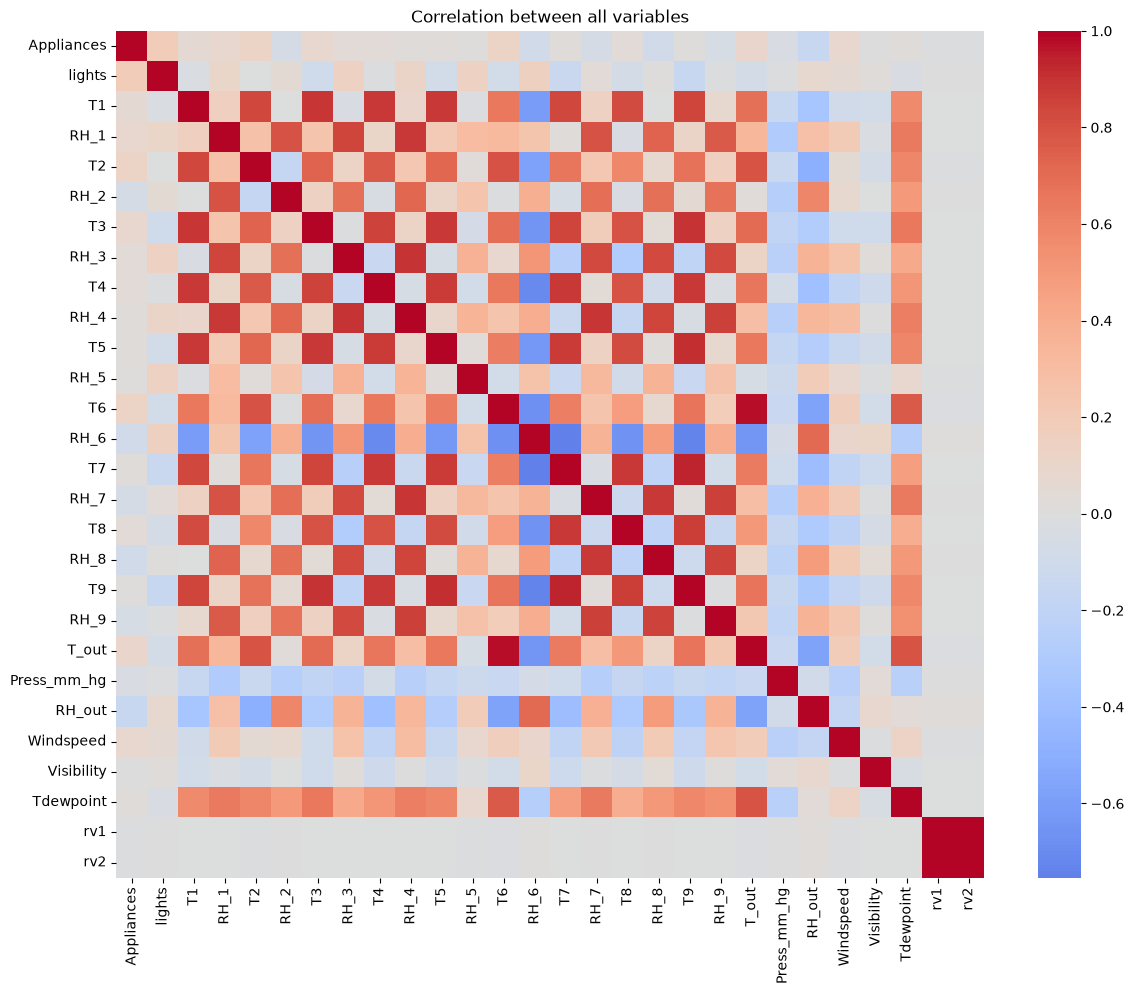

Appliances     1.000000
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


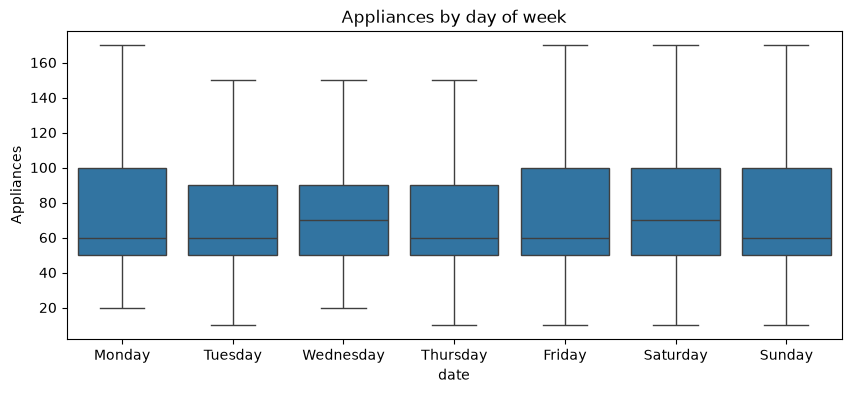

In [5]:
import seaborn as sns

plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation between all variables")
plt.show()

print(df.corr()["Appliances"].sort_values(ascending=False))

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(x=df.index.day_name(), y=df["Appliances"], order=days, showfliers=False)
plt.title("Appliances by day of week")
plt.show()

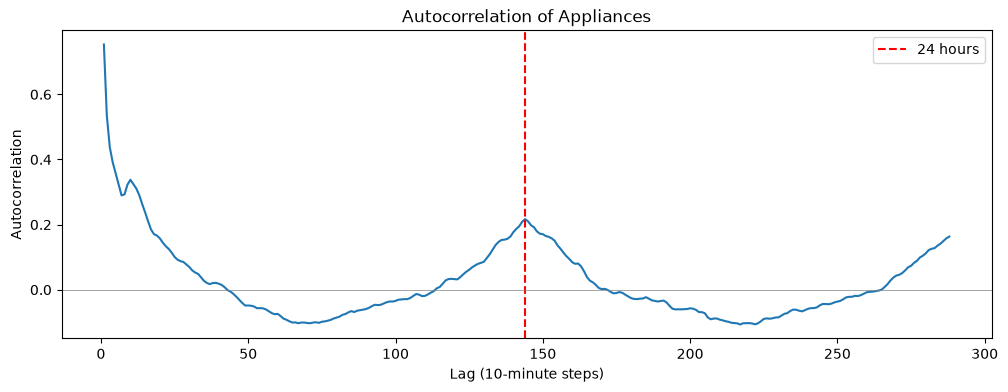

lag   1 (  10 min): 0.753
lag   2 (  20 min): 0.534
lag   3 (  30 min): 0.438
lag   6 (  60 min): 0.324
lag  12 ( 120 min): 0.311
lag  18 ( 180 min): 0.171
lag  36 ( 360 min): 0.021
lag  72 ( 720 min): -0.101
lag 144 (1440 min): 0.217


In [6]:
lags = range(1, 289)   # up to 48 hours (288 steps of 10 minutes)
acf = [df["Appliances"].autocorr(lag=k) for k in lags]

plt.figure(figsize=(12, 4))
plt.plot(lags, acf)
plt.axvline(144, color="red", linestyle="--", label="24 hours")
plt.axhline(0, color="grey", linewidth=0.5)
plt.xlabel("Lag (10-minute steps)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Appliances")
plt.legend()
plt.show()

for k in [1, 2, 3, 6, 12, 18, 36, 72, 144]:
    print(f"lag {k:>3} ({k * 10:>4} min): {df['Appliances'].autocorr(lag=k):.3f}")

In [7]:
import sys
sys.path.append("../src")
from feature_engineering import build_features

features = build_features(df)
print(features.shape)
print(features.columns.tolist())

features.to_csv("../data/processed/features.csv")

(19591, 52)
['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'app_lag_1', 'app_lag_2', 'app_lag_3', 'app_lag_6', 'app_lag_12', 'app_lag_144', 'app_diff_1', 'app_roll_mean_1h', 'app_roll_std_1h', 'app_roll_max_1h', 'app_roll_mean_3h', 'app_roll_std_3h', 'app_roll_max_3h', 'indoor_temp_mean', 'indoor_rh_mean', 'temp_gap_in_out', 'temp_x_rh', 'kitchen_rh_excess', 'NSM', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'is_holiday', 'weekend_hour_sin', 'weekend_hour_cos']


In [8]:
from data_preprocessing import chronological_split, split_xy, scale_features, to_wh

train, val, test = chronological_split(features)
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:<5} {len(part):>6} rows   {part.index.min()}  to  {part.index.max()}")

X_train, y_train = split_xy(train)
X_val, y_val = split_xy(val)
X_test, y_test = split_xy(test)
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)
print("Features:", X_train_s.shape[1])

train  13713 rows   2016-01-12 17:00:00  to  2016-04-16 22:20:00
val     1959 rows   2016-04-16 22:30:00  to  2016-04-30 12:50:00
test    3919 rows   2016-04-30 13:00:00  to  2016-05-27 18:00:00
Features: 51


                      MAE   RMSE  MAPE %    R2
model                                         
Naive (last value)  26.05  65.19   21.86  0.45
Linear Regression   27.26  66.49   22.12  0.43
Random Forest       26.51  58.30   23.19  0.56


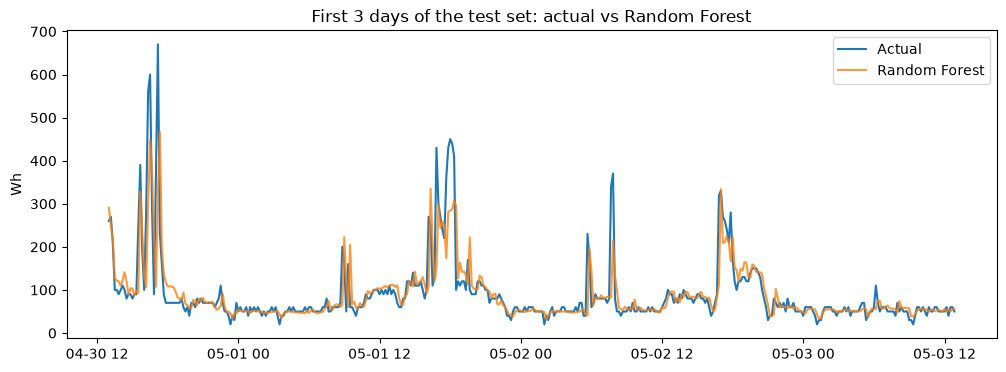

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(name, actual_wh, predicted_wh):
    """Return MAE, RMSE, MAPE and R2 for one model, all on the original Wh scale."""
    return {
        "model": name,
        "MAE": mean_absolute_error(actual_wh, predicted_wh),
        "RMSE": np.sqrt(mean_squared_error(actual_wh, predicted_wh)),
        "MAPE %": np.mean(np.abs((actual_wh - predicted_wh) / actual_wh)) * 100,
        "R2": r2_score(actual_wh, predicted_wh),
    }


actual = test["Appliances"].values
results = []

# Naive baseline: predict that the next reading equals the last one.
results.append(evaluate("Naive (last value)", actual, X_test["app_lag_1"].values))

linear = LinearRegression().fit(X_train_s, y_train)
results.append(evaluate("Linear Regression", actual, to_wh(linear.predict(X_test_s))))

forest = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)
forest.fit(X_train_s, y_train)
forest_pred = to_wh(forest.predict(X_test_s))
results.append(evaluate("Random Forest", actual, forest_pred))

baseline_results = pd.DataFrame(results).set_index("model").round(2)
print(baseline_results)

plt.figure(figsize=(12, 4))
plt.plot(test.index[:432], actual[:432], label="Actual")
plt.plot(test.index[:432], forest_pred[:432], label="Random Forest", alpha=0.8)
plt.title("First 3 days of the test set: actual vs Random Forest")
plt.ylabel("Wh")
plt.legend()
plt.show()

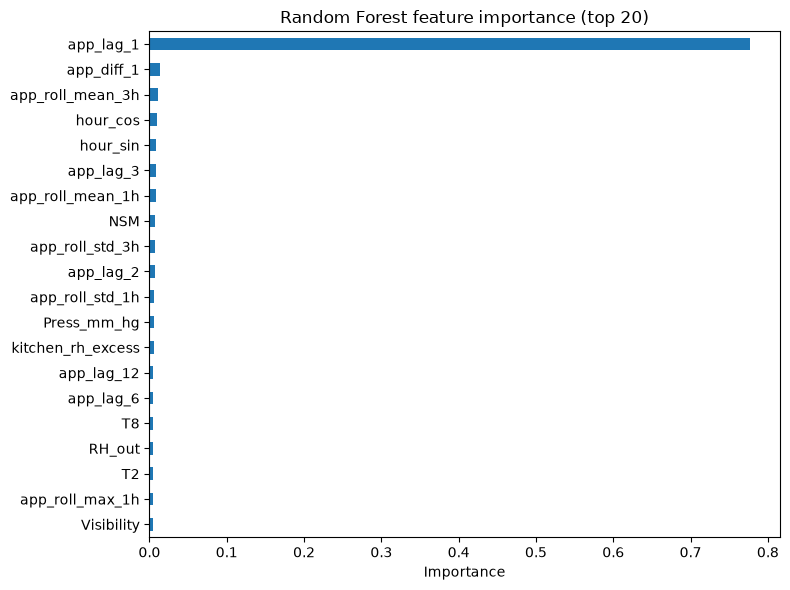

app_lag_1            0.7768
app_diff_1           0.0134
app_roll_mean_3h     0.0105
hour_cos             0.0103
hour_sin             0.0085
app_lag_3            0.0084
app_roll_mean_1h     0.0081
NSM                  0.0077
app_roll_std_3h      0.0074
app_lag_2            0.0073
app_roll_std_1h      0.0059
Press_mm_hg          0.0059
kitchen_rh_excess    0.0058
app_lag_12           0.0050
app_lag_6            0.0050
T8                   0.0049
RH_out               0.0048
T2                   0.0046
app_roll_max_1h      0.0046
Visibility           0.0045
T4                   0.0044
app_lag_144          0.0043
app_roll_max_3h      0.0043
RH_5                 0.0042
RH_2                 0.0042
RH_6                 0.0040
indoor_temp_mean     0.0036
RH_1                 0.0036
Windspeed            0.0036
RH_9                 0.0035
Tdewpoint            0.0035
T3                   0.0034
temp_gap_in_out      0.0033
RH_8                 0.0033
T9                   0.0032
T7                  

In [10]:
importance = pd.Series(forest.feature_importances_, index=X_train_s.columns).sort_values(ascending=False)

importance.head(20).sort_values().plot(
    kind="barh", figsize=(8, 6), title="Random Forest feature importance (top 20)"
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importance.round(4).to_string())

In [11]:
val_actual = val["Appliances"].values
rows = []
for k in [1, 5, 10, 15, 20, 30, 51]:
    cols = importance.index[:k]
    model = RandomForestRegressor(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=42)
    model.fit(X_train_s[cols], y_train)
    pred = to_wh(model.predict(X_val_s[cols]))
    rows.append({
        "features": k,
        "val MAE": mean_absolute_error(val_actual, pred),
        "val RMSE": np.sqrt(mean_squared_error(val_actual, pred)),
    })
print(pd.DataFrame(rows).set_index("features").round(2))

selected_features = list(importance.index[:10])
print(selected_features)

          val MAE  val RMSE
features                   
1           25.03     64.11
5           23.98     57.95
10          23.37     58.11
15          23.64     59.08
20          23.97     59.62
30          24.52     59.49
51          24.10     59.43
['app_lag_1', 'app_diff_1', 'app_roll_mean_3h', 'hour_cos', 'hour_sin', 'app_lag_3', 'app_roll_mean_1h', 'NSM', 'app_roll_std_3h', 'app_lag_2']


In [12]:
import importlib
import tensorflow as tf
import data_preprocessing
importlib.reload(data_preprocessing)  # picks up the updated file without restarting
from data_preprocessing import make_sequences
from model import build_lstm, default_callbacks

WINDOW = 12  # each sample sees the last 2 hours (12 x 10 minutes)

# Standardise the log target using training statistics only.
y_mean, y_std = y_train.mean(), y_train.std()

(X_train_seq, y_train_seq), (X_val_seq, y_val_seq), (X_test_seq, y_test_seq) = make_sequences(
    [X_train_s[selected_features], X_val_s[selected_features], X_test_s[selected_features]],
    [(y_train - y_mean) / y_std, (y_val - y_mean) / y_std, (y_test - y_mean) / y_std],
    WINDOW,
)
print("Train:", X_train_seq.shape, " Val:", X_val_seq.shape, " Test:", X_test_seq.shape)

Train: (13702, 12, 10)  Val: (1959, 12, 10)  Test: (3919, 12, 10)


In [13]:
tf.keras.utils.set_random_seed(42)

lstm = build_lstm(WINDOW, len(selected_features))
lstm.summary()

history = lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150,
    batch_size=64,
    callbacks=default_callbacks(),
    verbose=2,
)

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
215/215 - 4s - 17ms/step - loss: 0.4098 - mae: 0.4408 - val_loss: 0.2453 - val_mae: 0.3328 - learning_rate: 0.0010
Epoch 2/150
215/215 - 1s - 6ms/step - loss: 0.3142 - mae: 0.3757 - val_loss: 0.2210 - val_mae: 0.3146 - learning_rate: 0.0010
Epoch 3/150
215/215 - 1s - 7ms/step - loss: 0.2939 - mae: 0.3618 - val_loss: 0.2139 - val_mae: 0.3084 - learning_rate: 0.0010
Epoch 4/150
215/215 - 2s - 7ms/step - loss: 0.2879 - mae: 0.3570 - val_loss: 0.2122 - val_mae: 0.3083 - learning_rate: 0.0010
Epoch 5/150
215/215 - 2s - 7ms/step - loss: 0.2860 - mae: 0.3550 - val_loss: 0.2108 - val_mae: 0.3045 - learning_rate: 0.0010
Epoch 6/150
215/215 - 1s - 7ms/step - loss: 0.2827 - mae: 0.3539 - val_loss: 0.2097 - val_mae: 0.3042 - learning_rate: 0.0010
Epoch 7/150
215/215 - 1s - 6ms/step - loss: 0.2774 - mae: 0.3502 - val_loss: 0.2078 - val_mae: 0.3009 - learning_rate: 0.0010
Epoch 8/150
215/215 - 1s - 6ms/step - loss: 0.2785 - mae: 0.3503 - val_loss: 0.2085 - val_mae: 0.3052 - learning_rate

                      MAE   RMSE  MAPE %    R2
model                                         
Naive (last value)  26.05  65.19   21.86  0.45
Linear Regression   27.26  66.49   22.12  0.43
Random Forest       26.51  58.30   23.19  0.56
LSTM                23.41  56.78   19.38  0.58


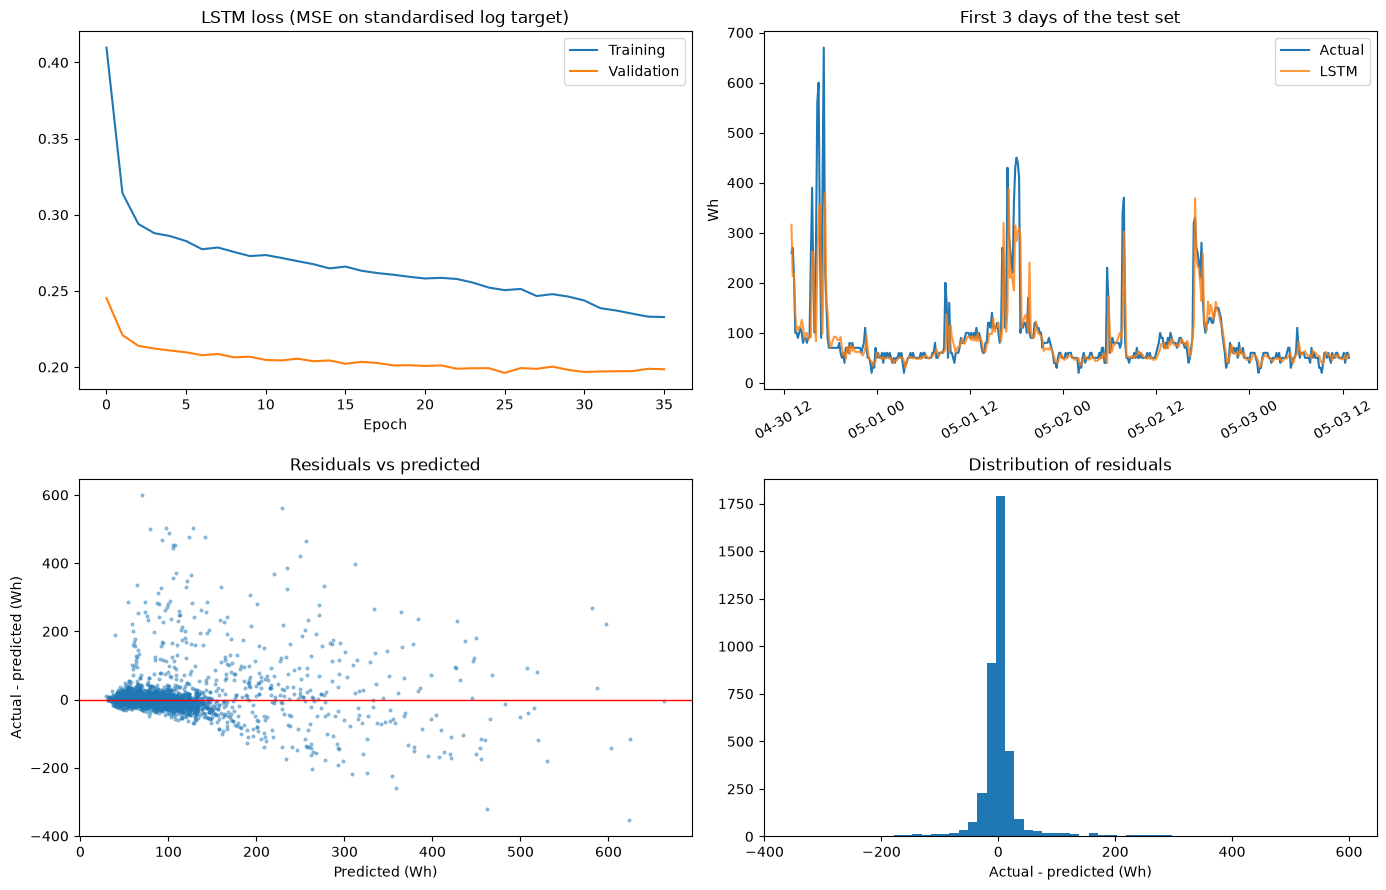

In [14]:
lstm_pred = to_wh(lstm.predict(X_test_seq, verbose=0).ravel() * y_std + y_mean)

lstm_row = pd.DataFrame([evaluate("LSTM", actual, lstm_pred)]).set_index("model").round(2)
comparison = pd.concat([baseline_results, lstm_row])
print(comparison)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(history.history["loss"], label="Training")
axes[0, 0].plot(history.history["val_loss"], label="Validation")
axes[0, 0].set_title("LSTM loss (MSE on standardised log target)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(test.index[:432], actual[:432], label="Actual")
axes[0, 1].plot(test.index[:432], lstm_pred[:432], label="LSTM", alpha=0.8)
axes[0, 1].set_title("First 3 days of the test set")
axes[0, 1].set_ylabel("Wh")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend()

residuals = actual - lstm_pred
axes[1, 0].scatter(lstm_pred, residuals, s=4, alpha=0.4)
axes[1, 0].axhline(0, color="red", linewidth=1)
axes[1, 0].set_title("Residuals vs predicted")
axes[1, 0].set_xlabel("Predicted (Wh)")
axes[1, 0].set_ylabel("Actual - predicted (Wh)")

axes[1, 1].hist(residuals, bins=60)
axes[1, 1].set_title("Distribution of residuals")
axes[1, 1].set_xlabel("Actual - predicted (Wh)")

plt.tight_layout()
plt.show()

In [15]:
import time
import importlib
import model as model_module
importlib.reload(model_module)  # picks up the updated model.py
from model import build_lstm, build_gru, build_cnn_lstm, build_stacked_lstm, default_callbacks

builders = {
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "Stacked LSTM": build_stacked_lstm,
}
SEEDS = [42, 7, 123]  # train each model 3 times to separate real differences from luck

val_actual = val["Appliances"].values
runs = []
for name, build in builders.items():
    for seed in SEEDS:
        tf.keras.utils.set_random_seed(seed)
        net = build(WINDOW, len(selected_features))
        start = time.time()
        fit = net.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=150, batch_size=64,
            callbacks=default_callbacks(), verbose=0,
        )
        val_pred = to_wh(net.predict(X_val_seq, verbose=0).ravel() * y_std + y_mean)
        runs.append({
            "model": name,
            "seed": seed,
            "parameters": net.count_params(),
            "epochs": len(fit.history["loss"]),
            "seconds": time.time() - start,
            "val MAE": mean_absolute_error(val_actual, val_pred),
            "val RMSE": np.sqrt(mean_squared_error(val_actual, val_pred)),
        })
        print(f"{name:<13} seed {seed:>3}:  val MAE {runs[-1]['val MAE']:.2f}   val RMSE {runs[-1]['val RMSE']:.2f}")

runs = pd.DataFrame(runs)
architecture_results = runs.groupby("model", sort=False).agg(
    parameters=("parameters", "first"),
    avg_epochs=("epochs", "mean"),
    avg_seconds=("seconds", "mean"),
    val_MAE=("val MAE", "mean"),
    val_MAE_std=("val MAE", "std"),
    val_RMSE=("val RMSE", "mean"),
).round(2)
display(architecture_results)

LSTM          seed  42:  val MAE 23.55   val RMSE 58.68
LSTM          seed   7:  val MAE 23.91   val RMSE 60.81
LSTM          seed 123:  val MAE 23.39   val RMSE 59.09
GRU           seed  42:  val MAE 23.94   val RMSE 59.88
GRU           seed   7:  val MAE 24.61   val RMSE 59.65
GRU           seed 123:  val MAE 23.84   val RMSE 60.20
CNN-LSTM      seed  42:  val MAE 22.96   val RMSE 58.69
CNN-LSTM      seed   7:  val MAE 23.22   val RMSE 57.90
CNN-LSTM      seed 123:  val MAE 22.98   val RMSE 58.39
Stacked LSTM  seed  42:  val MAE 23.66   val RMSE 60.06
Stacked LSTM  seed   7:  val MAE 23.67   val RMSE 58.81
Stacked LSTM  seed 123:  val MAE 23.13   val RMSE 59.40


,parameters,avg_epochs,avg_seconds,val_MAE,val_MAE_std,val_RMSE
model,,,,,,
LSTM,21313,40.00,48.04,23.61,0.27,59.53
GRU,16705,42.67,59.47,24.13,0.42,59.91
CNN-LSTM,27937,42.00,66.49,23.05,0.14,58.33
Stacked LSTM,32705,33.33,78.20,23.48,0.31,59.42


In [16]:
import importlib
import train as train_module
importlib.reload(train_module)
from train import SEARCH_SPACE, DEFAULT_CONFIG, sample_configs, run_trial

X_parts = [X_train_s[selected_features], X_val_s[selected_features], X_test_s[selected_features]]
y_parts = [y_train, y_val, y_test]

N_TRIALS = 20
configs = sample_configs(SEARCH_SPACE, N_TRIALS, seed=0)

search_rows = []
for i, config in enumerate(configs, start=1):
    metrics, _, _ = run_trial(config, X_parts, y_parts, y_mean, y_std, seed=42)
    search_rows.append(metrics)
    print(f"Trial {i:>2}/{N_TRIALS}: val MAE {metrics['val MAE']:.2f}  val RMSE {metrics['val RMSE']:.2f}  ({metrics['seconds']}s)  {config}")

search_results = pd.DataFrame(search_rows).sort_values("val MAE").round(3)
search_results.to_csv("../reports/random_search_results.csv", index=False)
print(search_results.head(10).to_string())

Trial  1/20: val MAE 24.02  val RMSE 60.63  (65s)  {'window': 12, 'filters': 32, 'kernel_size': 2, 'units': 64, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.001, 'batch_size': 64}
Trial  2/20: val MAE 23.52  val RMSE 59.94  (96s)  {'window': 12, 'filters': 32, 'kernel_size': 5, 'units': 32, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Trial  3/20: val MAE 23.87  val RMSE 59.58  (83s)  {'window': 6, 'filters': 64, 'kernel_size': 3, 'units': 128, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Trial  4/20: val MAE 23.28  val RMSE 58.40  (84s)  {'window': 24, 'filters': 16, 'kernel_size': 5, 'units': 64, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
Trial  5/20: val MAE 25.67  val RMSE 66.71  (20s)  {'window': 12, 'filters': 64, 'kernel_size': 5, 'units': 32, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.001, 'batch_size': 128}
Trial  6/20: val MAE 24.48  val RMSE 62.32  (31s)  {'w

In [17]:
search_results = pd.DataFrame(search_rows).sort_values("val MAE").round({"val MAE": 2, "val RMSE": 2})
search_results.to_csv("../reports/random_search_results.csv", index=False)
print(search_results.head(10).to_string())

    window  filters  kernel_size  units  dense_units  dropout  learning_rate  batch_size  seed  epochs  seconds  val MAE  val RMSE
6       24       16            5     64           32      0.2         0.0030          64    42      33       80    22.94     57.91
10      24       64            5     64           32      0.1         0.0030          64    42      21       71    23.18     58.90
3       24       16            5     64           32      0.1         0.0010          64    42      34       84    23.28     58.40
19      24       64            5    128           16      0.1         0.0003         128    42      68      312    23.28     59.09
13       6       16            2    128           64      0.4         0.0030         128    42      33       47    23.39     58.44
11      12       64            2     64           16      0.2         0.0003          32    42      58      222    23.40     58.36
12      24       64            3     64           16      0.1         0.0030       

In [18]:
HYPERPARAMETERS = list(SEARCH_SPACE)
top_configs = search_results.head(3)[HYPERPARAMETERS].to_dict("records")

recheck_rows = []
for rank, config in enumerate(top_configs, start=1):
    scores = [float(search_results.iloc[rank - 1]["val MAE"])]  # seed 42, from the search
    for seed in [7, 123]:
        metrics, _, _ = run_trial(config, X_parts, y_parts, y_mean, y_std, seed=seed)
        scores.append(metrics["val MAE"])
    recheck_rows.append({
        "rank": rank,
        **config,
        "seed 42": scores[0],
        "seed 7": scores[1],
        "seed 123": scores[2],
        "mean val MAE": np.mean(scores),
    })
    print(f"Rank {rank}: val MAE by seed {[round(s, 2) for s in scores]}  ->  mean {np.mean(scores):.2f}")

recheck = pd.DataFrame(recheck_rows).set_index("rank").round(2)
display(recheck)

Rank 1: val MAE by seed [22.94, 24.7, 23.64]  ->  mean 23.76
Rank 2: val MAE by seed [23.18, 24.05, 23.43]  ->  mean 23.55
Rank 3: val MAE by seed [23.28, 25.09, 23.69]  ->  mean 24.02


,window,filters,kernel_size,units,dense_units,dropout,learning_rate,batch_size,seed 42,seed 7,seed 123,mean val MAE
rank,,,,,,,,,,,,
1,24,16,5,64,32,0.2,0.0,64,22.94,24.70,23.64,23.76
2,24,64,5,64,32,0.1,0.0,64,23.18,24.05,23.43,23.55
3,24,16,5,64,32,0.1,0.0,64,23.28,25.09,23.69,24.02


In [21]:
recheck = pd.DataFrame(recheck_rows).set_index("rank").round({"seed 42": 2, "seed 7": 2, "seed 123": 2, "mean val MAE": 2})
display(recheck)

,window,filters,kernel_size,units,dense_units,dropout,learning_rate,batch_size,seed 42,seed 7,seed 123,mean val MAE
rank,,,,,,,,,,,,
1,24,16,5,64,32,0.2,0.003,64,22.94,24.70,23.64,23.76
2,24,64,5,64,32,0.1,0.003,64,23.18,24.05,23.43,23.55
3,24,16,5,64,32,0.1,0.001,64,23.28,25.09,23.69,24.02


In [19]:
DROPOUT_RATES = [0.0, 0.1, 0.2, 0.3, 0.4]
SEEDS = [42, 7, 123]

dropout_rows = []
dropout_models = {}
for rate in DROPOUT_RATES:
    for seed in SEEDS:
        config = {**DEFAULT_CONFIG, "dropout": rate}
        metrics, net, sequences = run_trial(config, X_parts, y_parts, y_mean, y_std, seed=seed)
        dropout_rows.append(metrics)
        dropout_models[(rate, seed)] = net
        print(f"dropout {rate}  seed {seed:>3}:  val MAE {metrics['val MAE']:.2f}   val RMSE {metrics['val RMSE']:.2f}")

dropout_results = pd.DataFrame(dropout_rows).groupby("dropout").agg(
    val_MAE=("val MAE", "mean"),
    val_MAE_std=("val MAE", "std"),
    val_RMSE=("val RMSE", "mean"),
    avg_epochs=("epochs", "mean"),
).round(2)
display(dropout_results)

dropout 0.0  seed  42:  val MAE 24.27   val RMSE 59.93
dropout 0.0  seed   7:  val MAE 24.00   val RMSE 58.46
dropout 0.0  seed 123:  val MAE 24.20   val RMSE 59.17
dropout 0.1  seed  42:  val MAE 23.65   val RMSE 59.81
dropout 0.1  seed   7:  val MAE 23.46   val RMSE 58.55
dropout 0.1  seed 123:  val MAE 23.22   val RMSE 58.41
dropout 0.2  seed  42:  val MAE 22.96   val RMSE 58.69
dropout 0.2  seed   7:  val MAE 23.22   val RMSE 57.90
dropout 0.2  seed 123:  val MAE 22.98   val RMSE 58.39
dropout 0.3  seed  42:  val MAE 22.95   val RMSE 58.07
dropout 0.3  seed   7:  val MAE 23.13   val RMSE 57.95
dropout 0.3  seed 123:  val MAE 22.92   val RMSE 58.66
dropout 0.4  seed  42:  val MAE 23.28   val RMSE 59.09
dropout 0.4  seed   7:  val MAE 23.35   val RMSE 60.05
dropout 0.4  seed 123:  val MAE 23.64   val RMSE 59.38


,val_MAE,val_MAE_std,val_RMSE,avg_epochs
dropout,,,,
0.0,24.16,0.14,59.19,37.00
0.1,23.44,0.21,58.92,47.00
0.2,23.05,0.14,58.33,42.00
0.3,23.00,0.11,58.23,46.67
0.4,23.42,0.19,59.51,65.33


Chosen dropout: 0.3
Validation MAE: single model 23.00  ->  3-seed ensemble 22.55


,MAE,RMSE,MAPE %,R2
model,,,,
Naive (last value),26.05,65.19,21.86,0.45
Linear Regression,27.26,66.49,22.12,0.43
Random Forest,26.51,58.30,23.19,0.56
LSTM,23.41,56.78,19.38,0.58
CNN-LSTM (before optimisation),23.70,57.55,19.72,0.57
CNN-LSTM ensemble (after optimisation),22.80,55.71,19.01,0.60


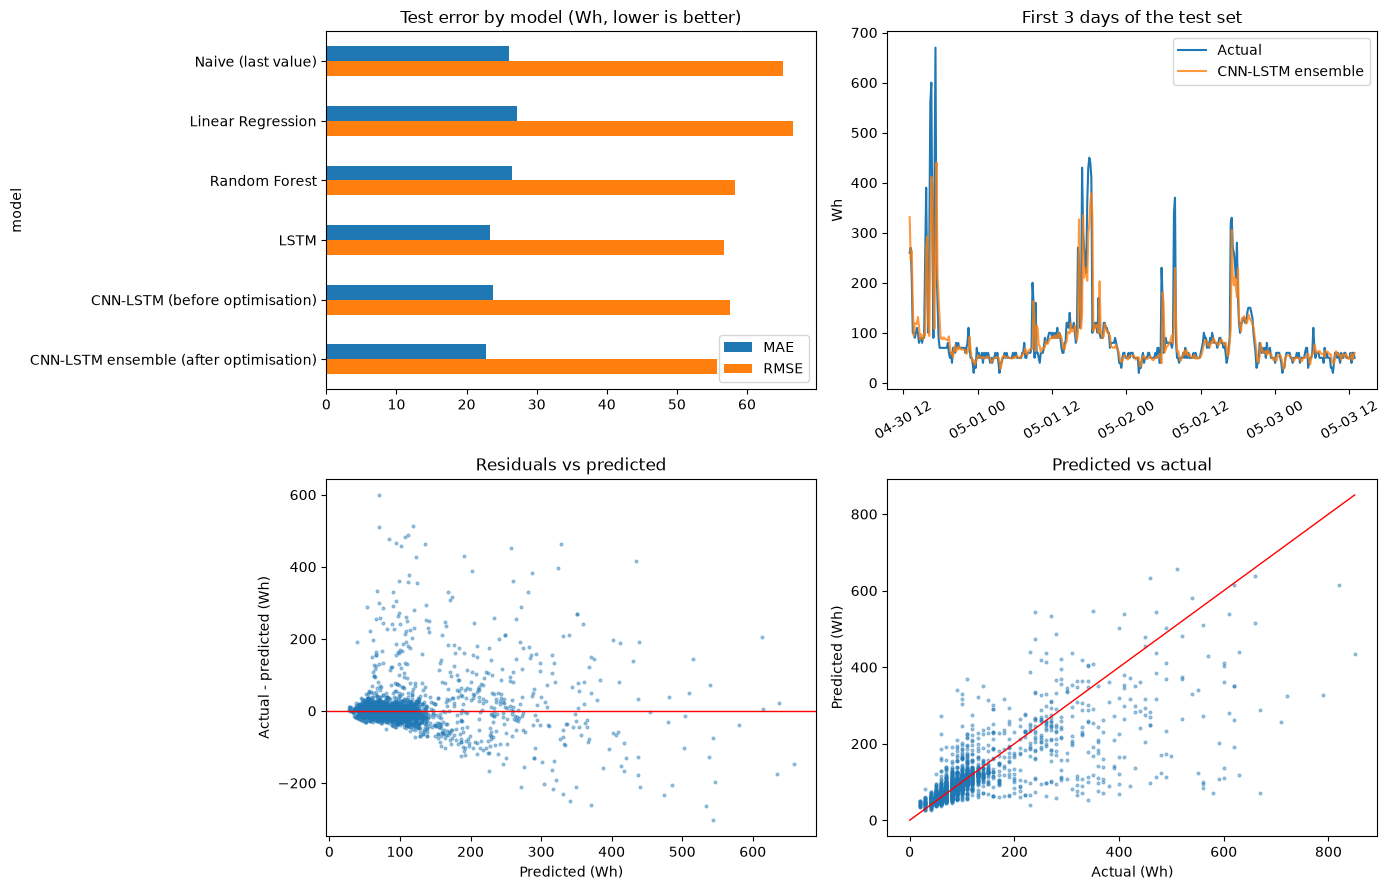

In [20]:
import os

BEST_DROPOUT = dropout_results["val_MAE"].idxmin()
print("Chosen dropout:", BEST_DROPOUT)

# All dropout runs use window 12, so they share the same sequences.
_, (X_val_seq, _), (X_test_seq, _) = sequences
val_actual = val["Appliances"].values


def predict_wh(models, X):
    """Average the Wh predictions of one or more models."""
    preds = [to_wh(m.predict(X, verbose=0).ravel() * y_std + y_mean) for m in models]
    return np.mean(preds, axis=0)


before_model = [dropout_models[(0.2, 42)]]                         # untuned CNN-LSTM, one seed
final_models = [dropout_models[(BEST_DROPOUT, s)] for s in SEEDS]  # best dropout, 3 seeds averaged

# Validation check: does averaging the seeds help?
val_single = np.mean([mean_absolute_error(val_actual, predict_wh([m], X_val_seq)) for m in final_models])
val_ensemble = mean_absolute_error(val_actual, predict_wh(final_models, X_val_seq))
print(f"Validation MAE: single model {val_single:.2f}  ->  3-seed ensemble {val_ensemble:.2f}")

# Test set: used only now, once the model is final.
before_pred = predict_wh(before_model, X_test_seq)
final_pred = predict_wh(final_models, X_test_seq)

final_comparison = pd.concat([
    comparison,
    pd.DataFrame([
        evaluate("CNN-LSTM (before optimisation)", actual, before_pred),
        evaluate("CNN-LSTM ensemble (after optimisation)", actual, final_pred),
    ]).set_index("model").round(2),
])
display(final_comparison)
final_comparison.to_csv("../reports/final_results.csv")

# Save the three ensemble members.
os.makedirs("../models", exist_ok=True)
for seed, m in zip(SEEDS, final_models):
    m.save(f"../models/cnn_lstm_seed{seed}.keras")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

final_comparison[["MAE", "RMSE"]].plot(kind="barh", ax=axes[0, 0])
axes[0, 0].set_title("Test error by model (Wh, lower is better)")
axes[0, 0].invert_yaxis()
axes[0, 0].legend(loc="lower right")

axes[0, 1].plot(test.index[:432], actual[:432], label="Actual")
axes[0, 1].plot(test.index[:432], final_pred[:432], label="CNN-LSTM ensemble", alpha=0.8)
axes[0, 1].set_title("First 3 days of the test set")
axes[0, 1].set_ylabel("Wh")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend()

final_residuals = actual - final_pred
axes[1, 0].scatter(final_pred, final_residuals, s=4, alpha=0.4)
axes[1, 0].axhline(0, color="red", linewidth=1)
axes[1, 0].set_title("Residuals vs predicted")
axes[1, 0].set_xlabel("Predicted (Wh)")
axes[1, 0].set_ylabel("Actual - predicted (Wh)")

axes[1, 1].scatter(actual, final_pred, s=4, alpha=0.4)
axes[1, 1].plot([0, actual.max()], [0, actual.max()], color="red", linewidth=1)
axes[1, 1].set_title("Predicted vs actual")
axes[1, 1].set_xlabel("Actual (Wh)")
axes[1, 1].set_ylabel("Predicted (Wh)")

plt.tight_layout()
plt.show()